# Verifying geom-distance from k-fold builder

Sanity-checks the per-train-run energy distance written into filenames by
`analysis/2026-04-27_build_kfold_splits.py`. For every fold:

1. Reload all 13 train + 3 val h5ads.
2. Re-fit the same joint PCA(50) on log-normalized train+val.
3. Compute the centroid (mean PC vector) of each run, plus the centroid of
   the concatenated val pool.
4. Plot all centroids in PC1/PC2, colouring train centroids by the
   recorded `edist` and marking val centroids separately.
5. Compare the recorded geomloss energy distance against a much simpler
   surrogate (Euclidean distance between centroids on the full 50-PC
   space) — they should be monotonically related if the geom distance
   is reasonable.

Reads h5ads from `data_local/.../kfold/{fold}/{train,val}/...`. This is a
sanity-check notebook — it displays plots inline only, nothing is written to
`analysis/final_results/`.

In [1]:
import json
import re
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

KFOLD_DIR = Path('/home/igor/igor_repos/scaling_laws/data_local/other/batch_effects/kfold')
FOLDS_PATH = KFOLD_DIR / 'folds.json'

N_PCS = 50
SEED = 0
FIG_DPI = 200

cfg = json.loads(FOLDS_PATH.read_text())
print(f'n_folds={cfg["n_folds"]}, n_pcs={cfg["n_pcs"]}, edist_subsample={cfg["edist_subsample"]}')
for f in cfg['folds']:
    print(f'  fold {f["fold"]}: val_ids={f["val_ids"]}  n_train_runs={len(f["train"])}')

n_folds=3, n_pcs=50, edist_subsample=5000
  fold 0: val_ids=['run_14', 'run_15', 'run_23']  n_train_runs=13
  fold 1: val_ids=['run_16', 'run_22', 'run_4']  n_train_runs=13
  fold 2: val_ids=['run_17', 'run_19', 'run_26']  n_train_runs=13


In [2]:
def fold_dir_name(fold_idx: int) -> str:
    return f'{fold_idx + 1}-fold'


def load_fold(fold_idx: int):
    """Return (train_adatas, val_adatas, train_ids, val_ids, train_edist)."""
    fold_cfg = cfg['folds'][fold_idx]
    base = KFOLD_DIR / fold_dir_name(fold_idx)
    val_ids = list(fold_cfg['val_ids'])
    val_adatas = [ad.read_h5ad(base / 'val' / f'{vid}.h5ad') for vid in val_ids]
    train_records = list(fold_cfg['train'])
    train_records.sort(key=lambda r: r['edist'])
    train_ids = [r['id'] for r in train_records]
    train_edist = np.asarray([r['edist'] for r in train_records], dtype=float)
    train_adatas = [ad.read_h5ad(KFOLD_DIR / r['file']) for r in train_records]
    return train_adatas, val_adatas, train_ids, val_ids, train_edist


def joint_pca(train_adatas, val_adatas, n_pcs=N_PCS):
    """Mirror `fold_pcs` from the build script: log-normalize then PCA."""
    combined = ad.concat(train_adatas + val_adatas, join='inner')
    sc.pp.normalize_total(combined, target_sum=1e4)
    sc.pp.log1p(combined)
    sc.pp.pca(combined, n_comps=n_pcs, random_state=SEED)
    pcs = np.asarray(combined.obsm['X_pca'])
    n_train_cells = sum(a.n_obs for a in train_adatas)
    return pcs[:n_train_cells], pcs[n_train_cells:]

In [3]:
results = []
for fold_idx in range(cfg['n_folds']):
    train_adatas, val_adatas, train_ids, val_ids, train_edist = load_fold(fold_idx)
    train_pcs, val_pcs = joint_pca(train_adatas, val_adatas)

    train_offsets = np.cumsum([0] + [a.n_obs for a in train_adatas])
    train_centroids = np.stack([
        train_pcs[train_offsets[i]:train_offsets[i + 1]].mean(axis=0)
        for i in range(len(train_ids))
    ])

    val_offsets = np.cumsum([0] + [a.n_obs for a in val_adatas])
    val_centroids = np.stack([
        val_pcs[val_offsets[i]:val_offsets[i + 1]].mean(axis=0)
        for i in range(len(val_ids))
    ])
    val_pool_centroid = val_pcs.mean(axis=0)

    centroid_dist = np.linalg.norm(train_centroids - val_pool_centroid, axis=1)

    results.append({
        'fold_idx': fold_idx,
        'fold_dir': fold_dir_name(fold_idx),
        'train_ids': train_ids,
        'val_ids': val_ids,
        'train_edist': train_edist,
        'train_centroids': train_centroids,
        'val_centroids': val_centroids,
        'val_pool_centroid': val_pool_centroid,
        'train_pcs': train_pcs,
        'val_pcs': val_pcs,
        'train_offsets': train_offsets,
        'val_offsets': val_offsets,
        'centroid_dist': centroid_dist,
    })
    print(
        f'fold {fold_idx} ({fold_dir_name(fold_idx)}): '
        f'train n={train_pcs.shape[0]}, val n={val_pcs.shape[0]}'
    )

fold 0 (1-fold): train n=130000, val n=30000
fold 1 (2-fold): train n=130000, val n=30000
fold 2 (3-fold): train n=130000, val n=30000


## PC1 / PC2 centroid maps

One subplot per fold. Each marker is one run's centroid (mean over its
10k cells) in joint-PCA space. Train centroids are coloured by the
recorded `edist` (the value baked into the filename); val centroids are
drawn as red squares and the val-pool centroid as a black star. If the
edist is meaningful, train centroids closer to the red/black markers
should sit at the cool end of the colormap and farther ones at the warm
end.

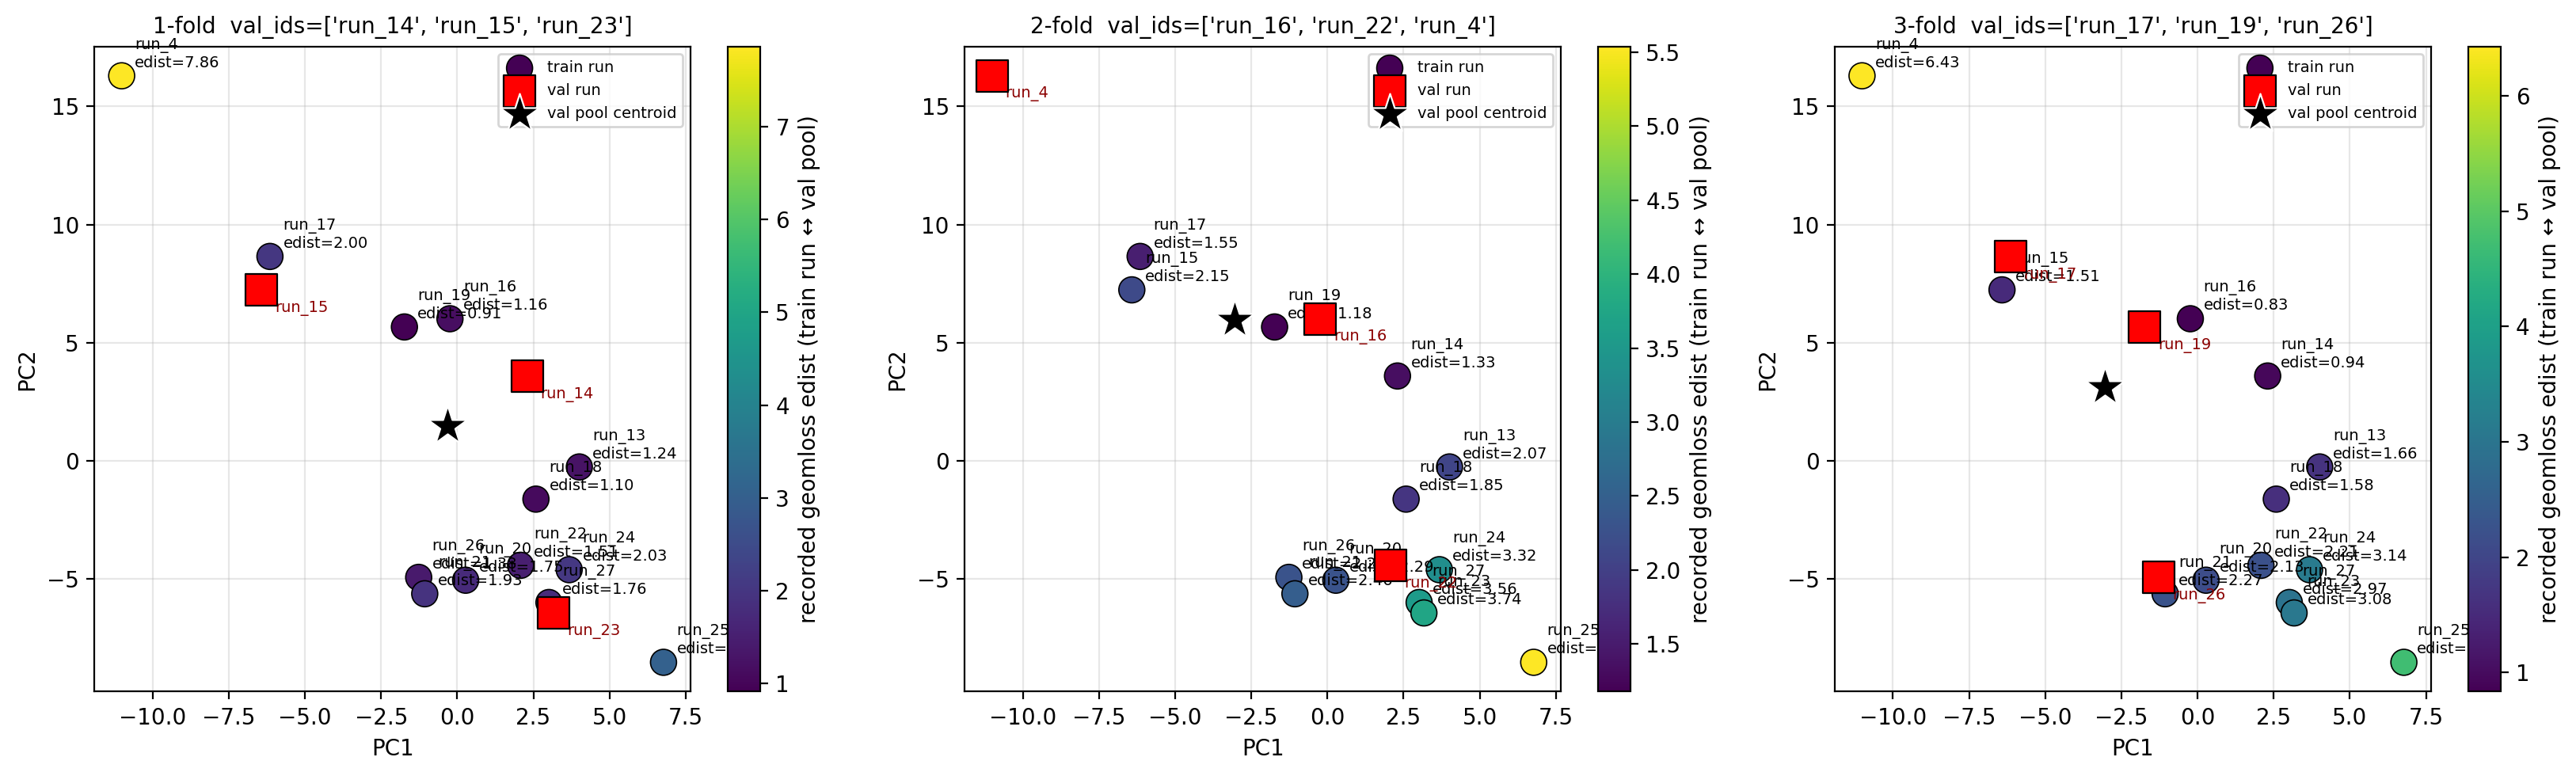

In [4]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 5.0), dpi=FIG_DPI)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    tc = r['train_centroids']
    vc = r['val_centroids']
    vp = r['val_pool_centroid']
    edist = r['train_edist']

    norm = Normalize(vmin=float(edist.min()), vmax=float(edist.max()))
    cmap = plt.get_cmap('viridis')
    sc_pts = ax.scatter(
        tc[:, 0], tc[:, 1], c=edist, cmap=cmap, norm=norm,
        s=140, edgecolors='k', linewidths=0.6, zorder=3, label='train run',
    )
    for tid, x_, y_, e in zip(r['train_ids'], tc[:, 0], tc[:, 1], edist):
        ax.annotate(
            f'{tid}\nedist={e:.2f}', xy=(x_, y_), xytext=(6, 4),
            textcoords='offset points', fontsize=7,
        )

    ax.scatter(
        vc[:, 0], vc[:, 1], c='red', marker='s', s=200, edgecolors='k',
        linewidths=0.8, zorder=4, label='val run',
    )
    for vid, x_, y_ in zip(r['val_ids'], vc[:, 0], vc[:, 1]):
        ax.annotate(
            vid, xy=(x_, y_), xytext=(6, -10),
            textcoords='offset points', fontsize=7, color='darkred',
        )
    ax.scatter(
        [vp[0]], [vp[1]], c='k', marker='*', s=350,
        edgecolors='white', linewidths=0.8, zorder=5, label='val pool centroid',
    )

    fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=ax,
        label='recorded geomloss edist (train run ↔ val pool)',
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{r["fold_dir"]}  val_ids={r["val_ids"]}', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=7, frameon=True)

fig.tight_layout()
plt.show()
plt.close(fig)

## All cells in PC1/PC2 — sanity overlay

A second view that draws every train cell as a small dot coloured by its
run's recorded `edist`, with val cells overlaid in red. Useful for
confirming the centroid summary isn't hiding heavy multi-modality within
a run.

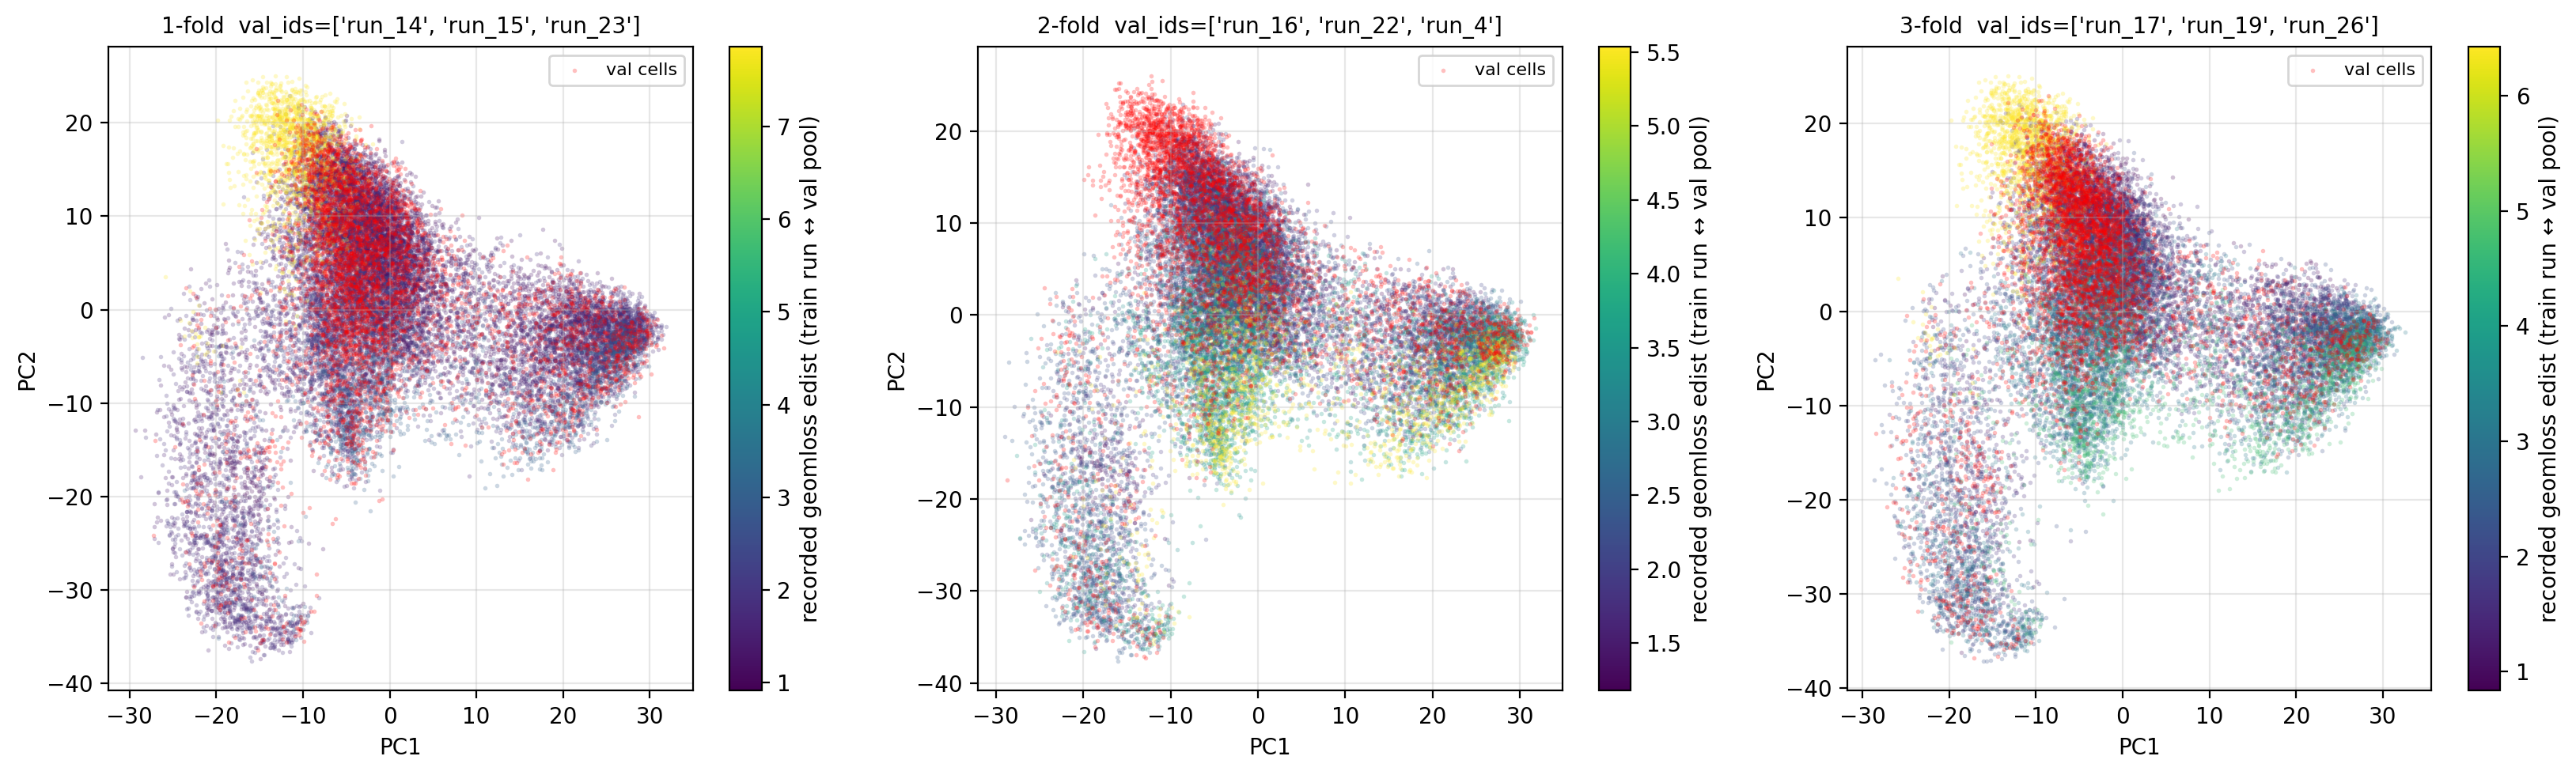

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 5.0), dpi=FIG_DPI)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    edist = r['train_edist']
    norm = Normalize(vmin=float(edist.min()), vmax=float(edist.max()))
    cmap = plt.get_cmap('viridis')

    train_pcs = r['train_pcs']
    offsets = r['train_offsets']
    rng = np.random.default_rng(SEED)
    for i, e in enumerate(edist):
        block = train_pcs[offsets[i]:offsets[i + 1]]
        if block.shape[0] > 1500:
            sel = rng.choice(block.shape[0], size=1500, replace=False)
            block = block[sel]
        ax.scatter(block[:, 0], block[:, 1], s=4, alpha=0.25,
                   color=cmap(norm(e)), linewidths=0)

    val_pcs = r['val_pcs']
    if val_pcs.shape[0] > 4500:
        sel = rng.choice(val_pcs.shape[0], size=4500, replace=False)
        val_pcs_s = val_pcs[sel]
    else:
        val_pcs_s = val_pcs
    ax.scatter(val_pcs_s[:, 0], val_pcs_s[:, 1], s=4, alpha=0.25,
               color='red', linewidths=0, label='val cells')

    fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=ax,
        label='recorded geomloss edist (train run ↔ val pool)',
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{r["fold_dir"]}  val_ids={r["val_ids"]}', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, frameon=True)

fig.tight_layout()
plt.show()
plt.close(fig)

## edist vs Euclidean centroid distance

If the recorded geomloss energy distance is sensible, it should agree
(at least monotonically) with the simplest possible distribution
summary: the Euclidean distance between each train run's centroid and
the val-pool centroid in 50-PC space. Strong rank correlation here is
what we want; large disagreements would point to the geom distance
being driven by spread / shape rather than location.

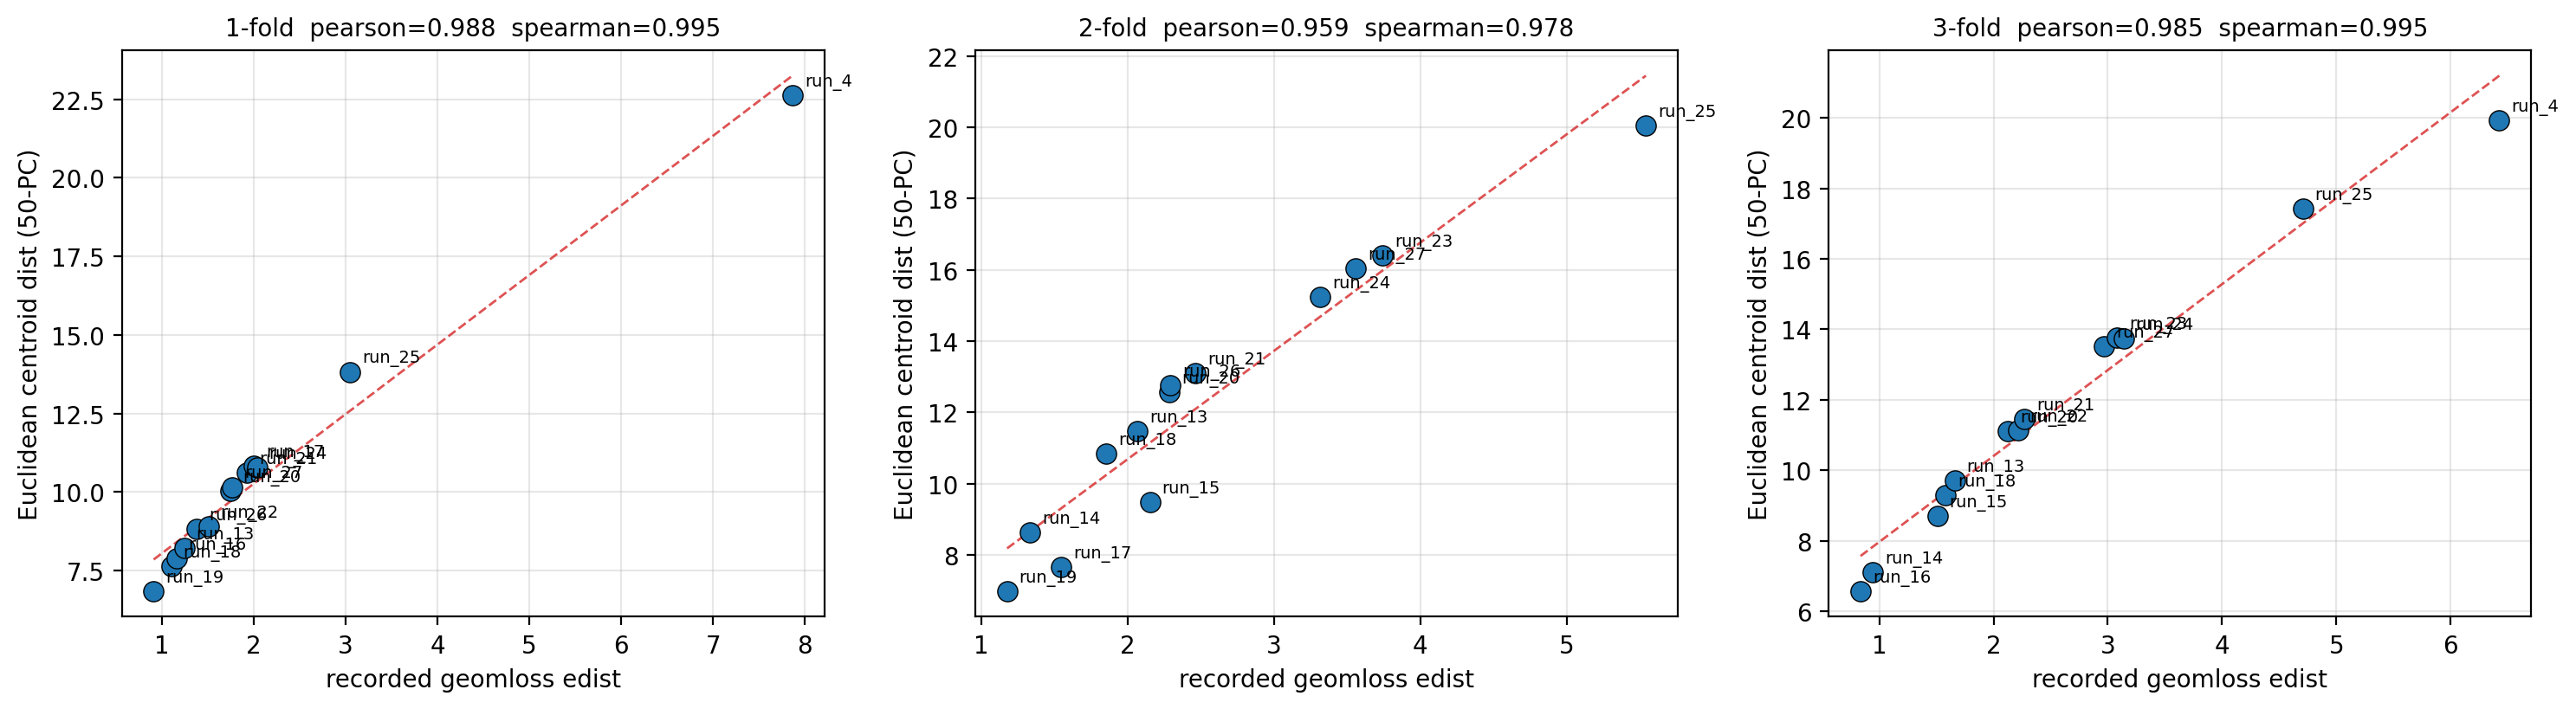

,fold,train_id,edist_recorded,centroid_dist_50pc
0,1-fold,run_19,0.911655,6.848752
1,1-fold,run_18,1.101635,7.643073
2,1-fold,run_16,1.159742,7.880311
3,1-fold,run_13,1.242821,8.224176
4,1-fold,run_26,1.382660,8.823514
5,1-fold,run_22,1.508755,8.907135
6,1-fold,run_20,1.748932,10.038980
7,1-fold,run_27,1.764950,10.158792
8,1-fold,run_21,1.929249,10.601174
9,1-fold,run_17,2.003050,10.822182


In [6]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, len(results), figsize=(5.0 * len(results), 4.2), dpi=FIG_DPI)
if len(results) == 1:
    axes = [axes]

rows = []
for ax, r in zip(axes, results):
    x = r['train_edist']
    y = r['centroid_dist']
    pearson = float(np.corrcoef(x, y)[0, 1])
    spearman = float(spearmanr(x, y).statistic)
    ax.scatter(x, y, s=70, c='C0', edgecolors='k', linewidths=0.5, zorder=3)
    for tid, xi, yi in zip(r['train_ids'], x, y):
        ax.annotate(tid, xy=(xi, yi), xytext=(5, 4),
                    textcoords='offset points', fontsize=7)
    if np.ptp(x) > 0:
        slope, intercept = np.polyfit(x, y, deg=1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, slope * xs + intercept, color='C3', linestyle='--',
                linewidth=1.0, alpha=0.8)
    ax.set_xlabel('recorded geomloss edist')
    ax.set_ylabel('Euclidean centroid dist (50-PC)')
    ax.set_title(
        f'{r["fold_dir"]}  pearson={pearson:.3f}  spearman={spearman:.3f}',
        fontsize=10,
    )
    ax.grid(alpha=0.3)
    for tid, e, cd in zip(r['train_ids'], x, y):
        rows.append({
            'fold': r['fold_dir'],
            'train_id': tid,
            'edist_recorded': e,
            'centroid_dist_50pc': cd,
        })

fig.tight_layout()
plt.show()
plt.close(fig)

summary_df = pd.DataFrame(rows).sort_values(['fold', 'edist_recorded']).reset_index(drop=True)
summary_df

## Filename consistency check

Cross-checks the `edist` recorded in `folds.json` against the value
encoded in each train h5ad's filename. They should match to the rounding
used by the build script (`{edist:.4f}`).

In [7]:
edist_re = re.compile(r'_edist([0-9.]+)\.h5ad$')
rows = []
for fold in cfg['folds']:
    for rec in fold['train']:
        m = edist_re.search(rec['file'])
        fname_edist = float(m.group(1)) if m else np.nan
        rows.append({
            'fold': fold_dir_name(fold['fold']),
            'run_id': rec['id'],
            'edist_json': rec['edist'],
            'edist_filename': fname_edist,
            'abs_diff': abs(rec['edist'] - fname_edist),
        })
check_df = pd.DataFrame(rows)
max_diff = check_df['abs_diff'].max()
print(f'max |edist_json - edist_filename| = {max_diff:.5f}')
check_df

max |edist_json - edist_filename| = 0.00005


,fold,run_id,edist_json,edist_filename,abs_diff
0,1-fold,run_13,1.242821,1.2428,0.000021
1,1-fold,run_16,1.159742,1.1597,0.000042
2,1-fold,run_17,2.003050,2.0030,0.000050
3,1-fold,run_18,1.101635,1.1016,0.000035
4,1-fold,run_19,0.911655,0.9117,0.000045
5,1-fold,run_20,1.748932,1.7489,0.000032
6,1-fold,run_21,1.929249,1.9292,0.000049
7,1-fold,run_22,1.508755,1.5088,0.000045
8,1-fold,run_24,2.034779,2.0348,0.000021
9,1-fold,run_25,3.049637,3.0496,0.000037
